# Qwen3Guard-Stream: потоковый baseline

Ноутбук запускает один токенный проход Qwen3Guard для каждой трассы, сохраняет его и затем воспроизводит шесть режимов буферизации с двумя политиками безопасности. Логика эксперимента импортируется из Python-пакета; полные чувствительные запросы и ответы не выводятся.

## 1. Конфигурация

`smoke` выбирает 5 безопасных и 5 опасных трасс. `full` использует все 500. Для локальной проверки без NVIDIA можно заменить `cuda` на `cpu`, но показатели времени после этого нельзя напрямую сравнивать с запуском на видеокарте.

In [ ]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from streamguard_bench.experiments import (
    load_boundary_dataset,
    load_experiment_run,
    run_experiment,
    select_profile_traces,
)
from streamguard_bench.guards import Qwen3GuardStreamAdapter
from streamguard_bench.metrics import compute_streaming_metrics

PROFILE = "full"  # "smoke" или "full"
RUN_MODEL = False  # False читает готовые файлы, True запускает Qwen3Guard
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RESUME = True
SEED = 42
DATASET_REVISION = "c36ddf315be89916c64fd6eb3b5a00ea6d505d1a"
MODEL_REVISION = "419364a715de9840d47b1457982f64ff37f90ed4"

MODES = ["token", "chunk_8", "chunk_16", "chunk_32", "sentence", "full_buffered"]
POLICIES = ["strict", "conservative"]
ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
OUTPUT_DIR = ROOT / "data/interim/qwen3guard_baseline"

## 2. Окружение

Эти сведения нужны для воспроизводимости задержки. Версии модели и токенизатора дополнительно сохраняются рядом с результатами.

In [2]:
environment = {
    "profile": PROFILE,
    "device": DEVICE,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "output_dir": str(OUTPUT_DIR),
}
pd.Series(environment, name="value")

profile                                                    full
device                                                      mps
python                                                  3.12.14
platform                           macOS-15.6.1-arm64-arm-64bit
output_dir    /Users/anastasia/Streaming-Guardrails/data/int...
Name: value, dtype: str

## 3. Загрузка и выбор трасс

Показываются только идентификаторы, итоговые метки и категории. Текст запросов и ответов остаётся внутри объекта данных.

In [3]:
if RUN_MODEL:
    dataset = load_boundary_dataset(
        revision=DATASET_REVISION,
        cache_dir=ROOT / "data/cache/huggingface",
    )
    selected = select_profile_traces(dataset, PROFILE, seed=SEED)
    print(f"Выбрано трасс: {len(selected)}")
    display(selected[["trace_id", "source_split", "label", "harm_categories"]])
else:
    dataset = None
    print("Датасет не загружается: используем сохранённый результат.")

/Users/anastasia/Streaming-Guardrails/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Выбрано трасс: 500


,trace_id,source_split,label,harm_categories
0,01496c9f9bd5353cdb6e,train,unsafe,"[Non-violent Illegal Acts, Personally Identifi..."
1,01d9b93e3ab6beada067,train,unsafe,"[Personally Identifiable Information, Unethica..."
2,03112c4130e4b640021c,train,unsafe,"[Non-violent Illegal Acts, Politically Sensiti..."
3,052d9264584ffb0ec8fa,train,safe,[]
4,0567d8ef4b5d7a96f439,train,unsafe,"[Non-violent Illegal Acts, Unethical Acts]"
...,...,...,...,...
495,fee24627b1416bd79070,train,unsafe,"[Non-violent Illegal Acts, Personally Identifi..."
496,ff06b88e4dc6c6738d7a,train,unsafe,"[Non-violent Illegal Acts, Copyright Violation]"
497,ff5de963621a43dd2912,val,unsafe,[Non-violent Illegal Acts]
498,ff6f3119716d9a2076ce,train,unsafe,"[Non-violent Illegal Acts, Unethical Acts, Pol..."


## 4. Загрузка Qwen3Guard

Загружается модель `Qwen/Qwen3Guard-Stream-0.6B`. Она не обучается: используются опубликованные веса.

In [4]:
if RUN_MODEL:
    guard = Qwen3GuardStreamAdapter(
        "Qwen/Qwen3Guard-Stream-0.6B",
        revision=MODEL_REVISION,
        tokenizer_revision=MODEL_REVISION,
        device=DEVICE,
    )
    print({
        "model": guard.model_id,
        "model_revision": guard.model_revision,
        "tokenizer_revision": guard.tokenizer_revision,
        "device": guard.device,
    })
else:
    guard = None
    print("Модель не загружается: используем сохранённый результат.")

`torch_dtype` is deprecated! Use `dtype` instead!


{'model': 'Qwen/Qwen3Guard-Stream-0.6B', 'model_revision': '419364a715de9840d47b1457982f64ff37f90ed4', 'tokenizer_revision': '419364a715de9840d47b1457982f64ff37f90ed4', 'device': 'mps'}


## 5. Запуск или продолжение

После каждой трассы токенные решения сохраняются в `data/interim`. При повторном запуске с `RESUME = True` завершённые трассы не вычисляются заново.

In [7]:
if RUN_MODEL:
    run = run_experiment(
        dataset=dataset,
        guard=guard,
        profile=PROFILE,
        modes=MODES,
        policies=POLICIES,
        output_dir=OUTPUT_DIR,
        resume=RESUME,
        seed=SEED,
        dataset_revision=DATASET_REVISION,
    )
else:
    run = load_experiment_run(OUTPUT_DIR, profile=PROFILE)
print(f"Результаты: {run.output_dir}")
print(f"Трасс: {len(run.selected_trace_ids)}; токенных решений: {len(run.token_decisions)}")

Результаты: /Users/anastasia/Streaming-Guardrails/data/interim/qwen3guard_baseline/full
Трасс: 500; токенных решений: 53980


## 6. Проверка полноты

Для `smoke` ожидается 120 строк, для `full` — 6000. Ошибка одной трассы представлена во всех 12 комбинациях, поэтому её нельзя незаметно принять за безопасный результат.

In [8]:
expected_traces = 10 if PROFILE == "smoke" else 500
expected_rows = expected_traces * len(MODES) * len(POLICIES)
assert len(run.results) == expected_rows, (len(run.results), expected_rows)
assert run.results[["trace_id", "mode", "policy"]].duplicated().sum() == 0
print(f"Строк: {len(run.results)} из {expected_rows}; ошибок трасс: {len(run.errors)}")
display(run.errors)

Строк: 6000 из 6000; ошибок трасс: 0


,trace_id,error_type,error


## 7. Как работают режимы и политики

Qwen3Guard получает токены **ответа модели** последовательно и сохраняет накопленный контекст: при проверке нового токена модель учитывает весь уже обработанный префикс. Режим определяет не контекст Qwen3Guard, а размер текста, который приложение удерживает скрытым перед показом пользователю.

### Режимы проверки

- **`token`** — каждый новый токен удерживается до решения Qwen3Guard. Если метка разрешена политикой, токен показывается; если запрещена — генерация блокируется до его показа.
- **`chunk_8`, `chunk_16`, `chunk_32`** — приложение скрыто накапливает соответственно 8, 16 или 32 новых токена. Например, в `chunk_16` сначала проверяются токены 1–16: если среди их решений нет блокирующей метки, весь фрагмент показывается; затем так же обрабатываются токены 17–32. Предыдущий фрагмент не входит в новый буфер показа, но Qwen3Guard его **не забывает** и продолжает учитывать весь префикс. Если внутри текущего чанка появился блокирующий сигнал, весь ещё не показанный чанк блокируется.
- **`sentence`** — текст удерживается до конца предложения и затем показывается либо блокируется целиком. Если знаков конца предложения долго нет, проверка принудительно завершается после 128 токенов.
- **`full_buffered`** — весь ответ остаётся скрытым до завершения генерации. Qwen3Guard по-прежнему оценивает его токен за токеном с накопленным контекстом; если блокирующий сигнал появился хотя бы один раз, пользователю не показывается весь ответ.

### Политики обработки меток

Qwen3Guard возвращает три класса: `Safe` — безопасно, `Controversial` — спорно или недостаточно уверенности, `Unsafe` — небезопасно.

- **`strict`** — блокирует только `Unsafe`; `Safe` и `Controversial` разрешает.
- **`conservative`** — блокирует `Unsafe` и `Controversial`; разрешает только `Safe`. Такая политика обычно раньше останавливает возможный вред, но может чаще блокировать безопасные ответы.

> **Важно:** результаты по 10 трассам проверяют работоспособность конвейера. Они не являются статистической оценкой качества Qwen3Guard. Исследовательские выводы можно делать только после профиля `full`.

In [9]:
metrics = compute_streaming_metrics(
    run.results,
    group_by=["mode", "policy"],
)
display(metrics)

,mode,policy,traces,failed_traces,safe_traces,unsafe_traces,blocked_traces,false_positives,false_negatives,false_positive_rate,...,released_tokens_mean,leakage_min_mean,leakage_max_mean,signal_token_mean,intervention_token_mean,detection_delay_min_mean,detection_delay_max_mean,checks_mean,guard_time_ms_median,guard_time_ms_p95
0,chunk_16,conservative,500,0,250,250,281,35,4,0.140,...,51.562,0.828,2.056,7.181495,19.565836,-12.593496,17.211382,3.998,1228.591168,20471.030047
1,chunk_16,strict,500,0,250,250,279,33,4,0.132,...,51.698,0.828,2.056,6.014337,18.444444,-12.593496,17.211382,4.006,1228.591168,20471.030047
2,chunk_32,conservative,500,0,250,250,281,35,4,0.140,...,51.082,0.764,1.608,7.181495,34.060498,2.268293,32.073171,2.374,2512.944625,20471.030047
3,chunk_32,strict,500,0,250,250,279,33,4,0.132,...,51.218,0.764,1.608,6.014337,32.928315,2.268293,32.073171,2.378,2512.944625,20471.030047
4,chunk_8,conservative,500,0,250,250,281,35,4,0.140,...,52.186,0.828,3.080,7.181495,12.697509,-19.528455,10.276423,7.284,942.282727,20471.030047
5,chunk_8,strict,500,0,250,250,279,33,4,0.132,...,52.306,0.828,3.080,6.014337,11.555556,-19.528455,10.276423,7.298,942.282727,20471.030047
6,full_buffered,conservative,500,0,250,250,281,35,4,0.140,...,49.546,0.584,0.840,7.181495,103.939502,71.548780,101.353659,1.000,10367.002810,23433.065757
7,full_buffered,strict,500,0,250,250,279,33,4,0.132,...,50.322,0.584,0.840,6.014337,103.293907,71.548780,101.353659,1.000,10367.002810,23433.065757
8,sentence,conservative,500,0,250,250,281,35,4,0.140,...,51.178,0.784,1.924,7.181495,28.747331,-2.626016,27.178862,3.352,2588.675397,20471.030047
9,sentence,strict,500,0,250,250,279,33,4,0.132,...,51.334,0.784,1.924,6.014337,27.630824,-2.626016,27.178862,3.356,2588.675397,20471.030047


## 8. Сравнение режимов

Графики строятся только по агрегатам. Полные чувствительные ответы не отображаются.

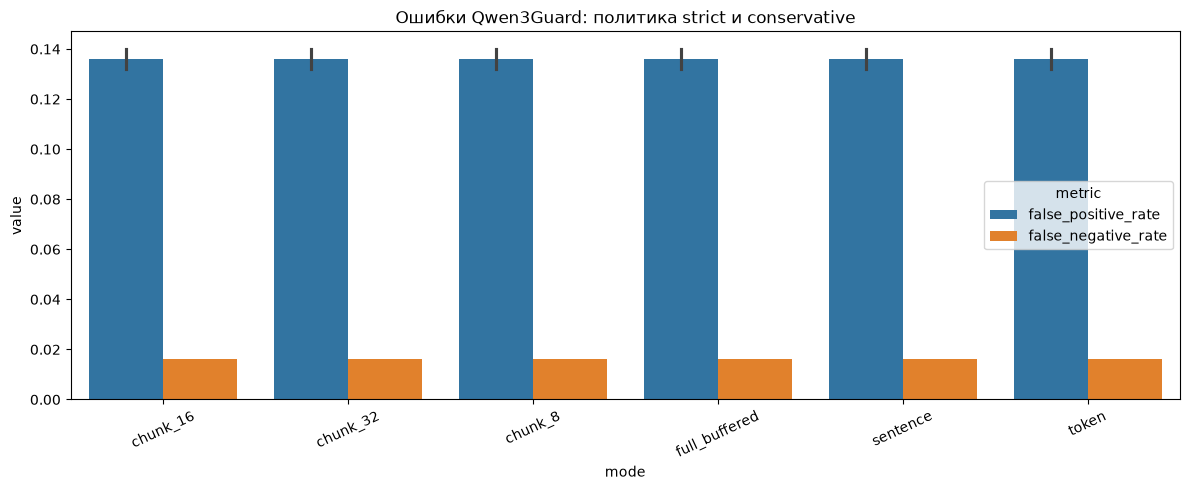

In [10]:
plot_data = metrics.melt(
    id_vars=["mode", "policy"],
    value_vars=["false_positive_rate", "false_negative_rate"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_data, x="mode", y="value", hue="metric")
plt.title(f"Ошибки Qwen3Guard: политика {POLICIES[0]} и {POLICIES[1]}")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 9. Ошибки без чувствительного текста

In [11]:
if run.errors.empty:
    print("Все выбранные трассы обработаны успешно.")
else:
    display(run.errors[["trace_id", "error_type", "error"]])

Все выбранные трассы обработаны успешно.


## 10. Интерпретация результатов

Смотрим на trade-off между "утечкой" и задержкой показа по режимам буферизации.
Пока считаем по всем 500 трассам сразу (safe + unsafe)

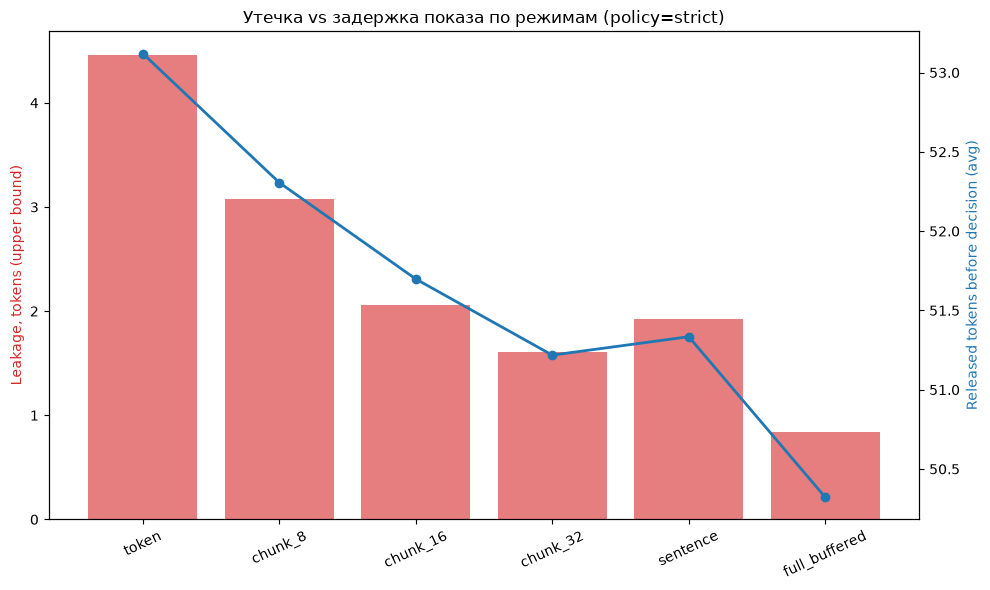

In [14]:
tradeoff = metrics[metrics["policy"] == POLICIES[0]].copy()
mode_order = ["token", "chunk_8", "chunk_16", "chunk_32", "sentence", "full_buffered"]
tradeoff["mode"] = pd.Categorical(tradeoff["mode"], categories=mode_order, ordered=True)
tradeoff = tradeoff.sort_values("mode")

fig, ax1 = plt.subplots(figsize=(10, 6))
x = range(len(tradeoff))

ax1.bar(x, tradeoff["leakage_max_mean"], color="tab:red", alpha=0.6, label="leakage_max_mean (tokens, avg over all traces)")
ax1.set_ylabel("Leakage, tokens (upper bound)", color="tab:red")
ax1.set_xticks(x)
ax1.set_xticklabels(tradeoff["mode"], rotation=25)

ax2 = ax1.twinx()
ax2.plot(x, tradeoff["released_tokens_mean"], color="tab:blue", marker="o", linewidth=2, label="released_tokens_mean")
ax2.set_ylabel("Released tokens before decision (avg)", color="tab:blue")

plt.title(f"Утечка vs задержка показа по режимам (policy={POLICIES[0]})")
fig.tight_layout()
plt.show()

leakage считается от точки release (сколько отдали пользователю), а detection_delay —
от точки intervention относительно начала вреда (onset). Это две разные вещи, и стоит
смотреть на них рядом, а не по отдельности — иначе легко решить, что режим с меньшим
leakage "безопаснее", хотя он может медленнее реагировать на уже начавшийся вред.

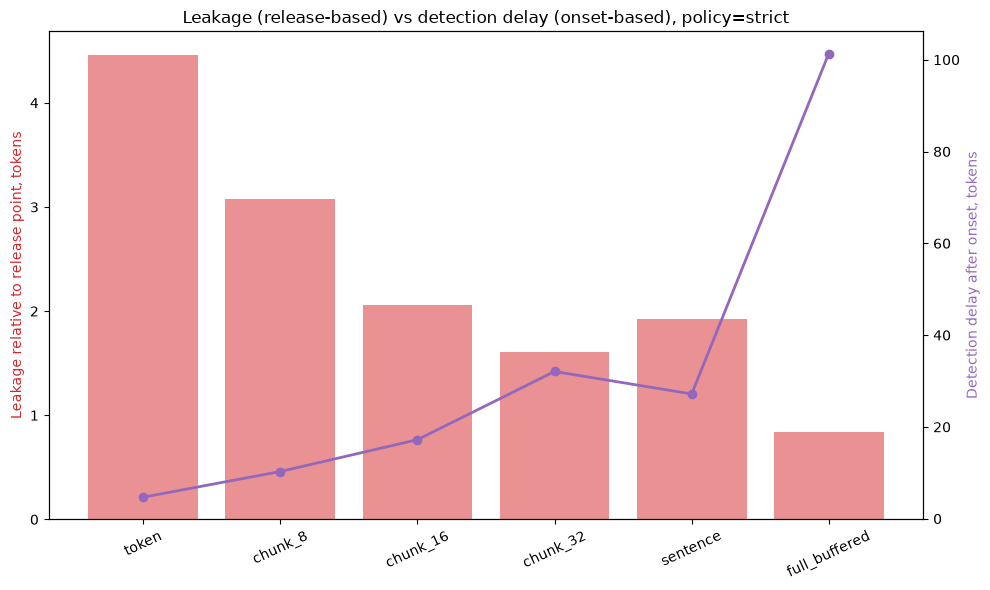

In [15]:
mode_order = ["token", "chunk_8", "chunk_16", "chunk_32", "sentence", "full_buffered"]
tradeoff = metrics[metrics["policy"] == POLICIES[0]].copy()
tradeoff["mode"] = pd.Categorical(tradeoff["mode"], categories=mode_order, ordered=True)
tradeoff = tradeoff.sort_values("mode")

fig, ax1 = plt.subplots(figsize=(10, 6))
x = range(len(tradeoff))

ax1.bar(x, tradeoff["leakage_max_mean"], color="tab:red", alpha=0.5, label="leakage_max_mean")
ax1.set_ylabel("Leakage relative to release point, tokens", color="tab:red")
ax1.set_xticks(x)
ax1.set_xticklabels(tradeoff["mode"], rotation=25)

ax2 = ax1.twinx()
ax2.plot(x, tradeoff["detection_delay_max_mean"], color="tab:purple", marker="o", linewidth=2, label="detection_delay_max_mean")
ax2.set_ylabel("Detection delay after onset, tokens", color="tab:purple")

plt.title(f"Leakage (release-based) vs detection delay (onset-based), policy={POLICIES[0]}")
fig.tight_layout()
plt.show()

In [17]:
unsafe_results = run.results[run.results["ground_truth_label"] == "unsafe"]
metrics_unsafe = compute_streaming_metrics(unsafe_results, group_by=["mode", "policy"])
display(metrics_unsafe)

,mode,policy,traces,failed_traces,safe_traces,unsafe_traces,blocked_traces,false_positives,false_negatives,false_positive_rate,...,released_tokens_mean,leakage_min_mean,leakage_max_mean,signal_token_mean,intervention_token_mean,detection_delay_min_mean,detection_delay_max_mean,checks_mean,guard_time_ms_median,guard_time_ms_p95
0,chunk_16,conservative,250,0,0,250,246,0,4,NaN,...,2.056,0.828,2.056,4.682927,17.211382,-12.593496,17.211382,1.120,978.814561,1433.158794
1,chunk_16,strict,250,0,0,250,246,0,4,NaN,...,2.056,0.828,2.056,4.682927,17.211382,-12.593496,17.211382,1.120,978.814561,1433.158794
2,chunk_32,conservative,250,0,0,250,246,0,4,NaN,...,1.608,0.764,1.608,4.682927,32.073171,2.268293,32.073171,1.044,2121.427542,2707.640307
3,chunk_32,strict,250,0,0,250,246,0,4,NaN,...,1.608,0.764,1.608,4.682927,32.073171,2.268293,32.073171,1.044,2121.427542,2707.640307
4,chunk_8,conservative,250,0,0,250,246,0,4,NaN,...,3.080,0.828,3.080,4.682927,10.276423,-19.528455,10.276423,1.376,487.058145,1178.597344
5,chunk_8,strict,250,0,0,250,246,0,4,NaN,...,3.080,0.828,3.080,4.682927,10.276423,-19.528455,10.276423,1.376,487.058145,1178.597344
6,full_buffered,conservative,250,0,0,250,246,0,4,NaN,...,0.840,0.584,0.840,4.682927,101.353659,71.548780,101.353659,1.000,9386.531411,24448.454424
7,full_buffered,strict,250,0,0,250,246,0,4,NaN,...,0.840,0.584,0.840,4.682927,101.353659,71.548780,101.353659,1.000,9386.531411,24448.454424
8,sentence,conservative,250,0,0,250,246,0,4,NaN,...,1.924,0.784,1.924,4.682927,27.178862,-2.626016,27.178862,1.100,1564.303480,4150.829340
9,sentence,strict,250,0,0,250,246,0,4,NaN,...,1.924,0.784,1.924,4.682927,27.178862,-2.626016,27.178862,1.100,1564.303480,4150.829340


Пересчитываем метрики только на unsafe-трассах. В общем `metrics` released_tokens
и leakage усредняются по всем 500 трассам, а у safe они всегда 0 (или равны длине
всей трассы для released) — это гасит разницу между режимами. На unsafe-only
разброс между режимами должен быть заметнее и интерпретируемее.

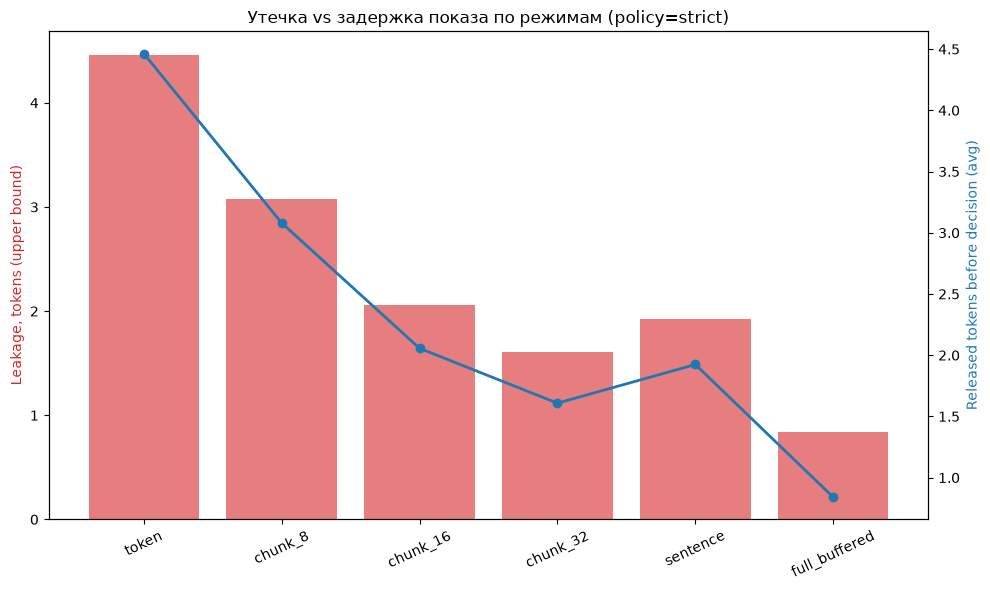

In [18]:
tradeoff = metrics_unsafe[metrics_unsafe["policy"] == POLICIES[0]].copy()
mode_order = ["token", "chunk_8", "chunk_16", "chunk_32", "sentence", "full_buffered"]
tradeoff["mode"] = pd.Categorical(tradeoff["mode"], categories=mode_order, ordered=True)
tradeoff = tradeoff.sort_values("mode")

fig, ax1 = plt.subplots(figsize=(10, 6))
x = range(len(tradeoff))

ax1.bar(x, tradeoff["leakage_max_mean"], color="tab:red", alpha=0.6, label="leakage_max_mean (tokens, avg over all traces)")
ax1.set_ylabel("Leakage, tokens (upper bound)", color="tab:red")
ax1.set_xticks(x)
ax1.set_xticklabels(tradeoff["mode"], rotation=25)

ax2 = ax1.twinx()
ax2.plot(x, tradeoff["released_tokens_mean"], color="tab:blue", marker="o", linewidth=2, label="released_tokens_mean")
ax2.set_ylabel("Released tokens before decision (avg)", color="tab:blue")

plt.title(f"Утечка vs задержка показа по режимам (policy={POLICIES[0]})")
fig.tight_layout()
plt.show()

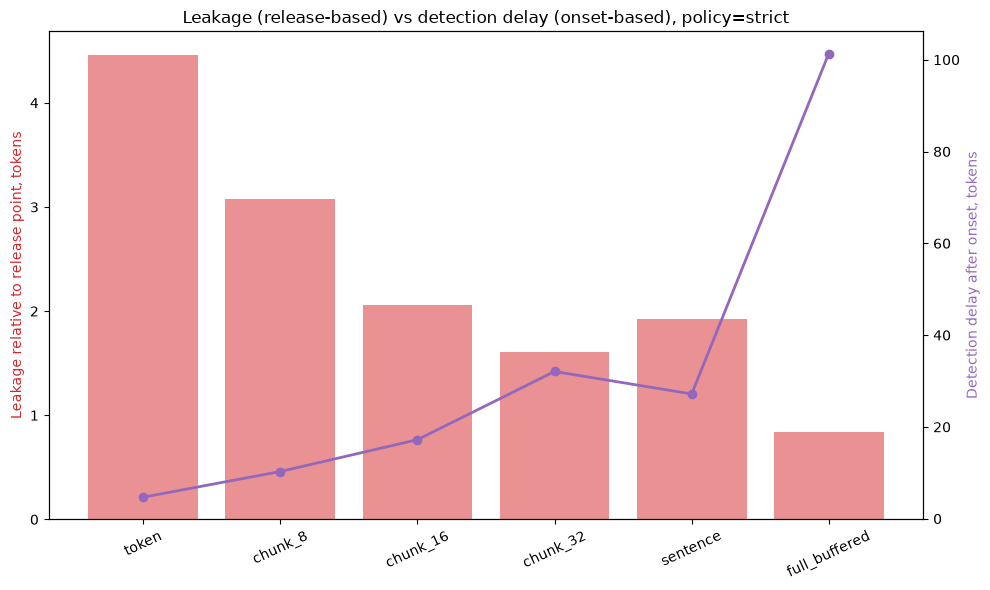

In [19]:
mode_order = ["token", "chunk_8", "chunk_16", "chunk_32", "sentence", "full_buffered"]
tradeoff = metrics_unsafe[metrics_unsafe["policy"] == POLICIES[0]].copy()
tradeoff["mode"] = pd.Categorical(tradeoff["mode"], categories=mode_order, ordered=True)
tradeoff = tradeoff.sort_values("mode")

fig, ax1 = plt.subplots(figsize=(10, 6))
x = range(len(tradeoff))

ax1.bar(x, tradeoff["leakage_max_mean"], color="tab:red", alpha=0.5, label="leakage_max_mean")
ax1.set_ylabel("Leakage relative to release point, tokens", color="tab:red")
ax1.set_xticks(x)
ax1.set_xticklabels(tradeoff["mode"], rotation=25)

ax2 = ax1.twinx()
ax2.plot(x, tradeoff["detection_delay_max_mean"], color="tab:purple", marker="o", linewidth=2, label="detection_delay_max_mean")
ax2.set_ylabel("Detection delay after onset, tokens", color="tab:purple")

plt.title(f"Leakage (release-based) vs detection delay (onset-based), policy={POLICIES[0]}")
fig.tight_layout()
plt.show()

Смотрим, на каком токене модель впервые даёт сигнал риска на unsafe-трассах.
Это первопричина всех различий между режимами буферизации — если сигнал
концентрируется в первых токенах, это объясняет, почему у token leakage такой
маленький в абсолютных числах, и почему у чанковых режимов разброс большой.

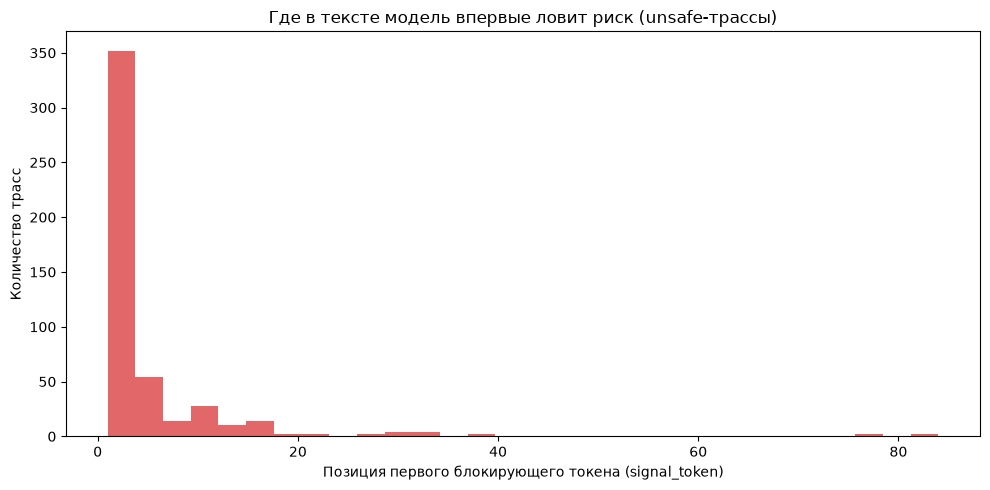

In [20]:
signal_data = run.results[
    (run.results["ground_truth_label"] == "unsafe")
    & (run.results["mode"] == "token")
    & (run.results["signal_token"].notna())
]

plt.figure(figsize=(10, 5))
plt.hist(signal_data["signal_token"], bins=30, color="tab:red", alpha=0.7)
plt.xlabel("Позиция первого блокирующего токена (signal_token)")
plt.ylabel("Количество трасс")
plt.title("Где в тексте модель впервые ловит риск (unsafe-трассы)")
plt.tight_layout()
plt.show()

Задержка в токенах — не единственная цена буферизации. checks_mean показывает,
сколько раз guard вообще вызывался на трассу (для token — почти на каждом токене,
для chunk_32 — в разы реже), а guard_time_ms — реальное время работы. Это важно
для практического выбора режима: token может быть безопаснее, но дороже по вызовам.

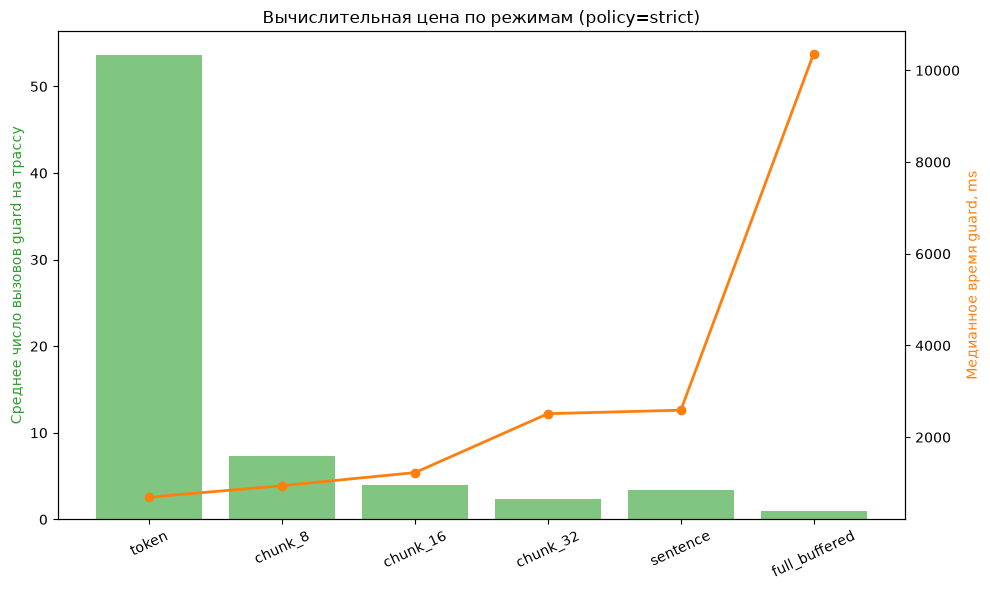

In [21]:
compute_cost = metrics[metrics["policy"] == POLICIES[0]].copy()
compute_cost["mode"] = pd.Categorical(compute_cost["mode"], categories=mode_order, ordered=True)
compute_cost = compute_cost.sort_values("mode")

fig, ax1 = plt.subplots(figsize=(10, 6))
x = range(len(compute_cost))

ax1.bar(x, compute_cost["checks_mean"], color="tab:green", alpha=0.6, label="checks_mean")
ax1.set_ylabel("Среднее число вызовов guard на трассу", color="tab:green")
ax1.set_xticks(x)
ax1.set_xticklabels(compute_cost["mode"], rotation=25)

ax2 = ax1.twinx()
ax2.plot(x, compute_cost["guard_time_ms_median"], color="tab:orange", marker="o", linewidth=2, label="guard_time_ms_median")
ax2.set_ylabel("Медианное время guard, ms", color="tab:orange")

plt.title(f"Вычислительная цена по режимам (policy={POLICIES[0]})")
fig.tight_layout()
plt.show()

## 11. Выводы

**Качество классификации.** FNR = 1.6% (4 из 250 unsafe пропущены, одинаково для
обеих политик), FPR = 13.2% (strict) / 14.0% (conservative). Разница между политиками
небольшая, но не нулевая: conservative блокирует на 2 safe-трассы больше, при этом
не спасает ни одной из 4 упущенных unsafe — то есть метка Controversial здесь влияет
только на over-blocking, а не на recall.

**Буферизация не влияет на факт блокировки** (это решает один и тот же токенный
прогон модели), но сильно влияет на когда: задержка обнаружения растёт от token
(~5 токенов после начала вреда) до full_buffered (~101), а формальная leakage
падает в обратную сторону (4.5 → 0.84). Это не значит, что full_buffered
безопаснее — медиана leakage у него равна 0, то есть вне четырёх пропущенных
трасс частичной утечки нет вообще; всё среднее значение (0.84) — это цена
именно этих 4 ошибок классификатора, а не свойство самого режима.

Вывод: token и full_buffered — два разных контракта с пользователем (скорость
реакции vs нулевой частичный показ), а не хороший и плохой вариант. Sentence
не даёт выигрыша, оправдывающего сложность — лежит между chunk_16 и chunk_32
по всем метрикам.

**Вычислительная цена** идёт в обратную сторону: token — 53.7 вызова guard на
трассу, full_buffered — 1. Это третья ось того же trade-off.